Saved CSV to: my_datasets\binary_clean.csv


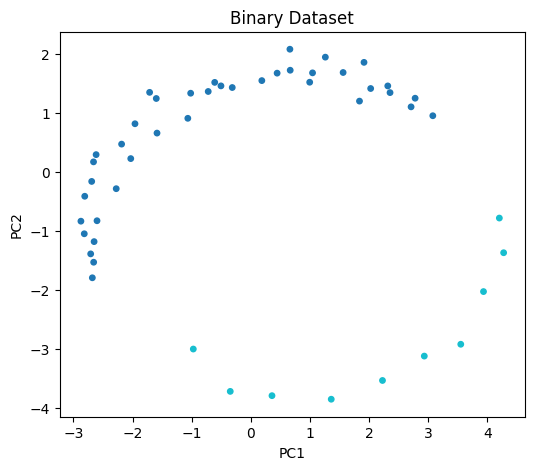

Saved CSV to: my_datasets\multi_clean.csv


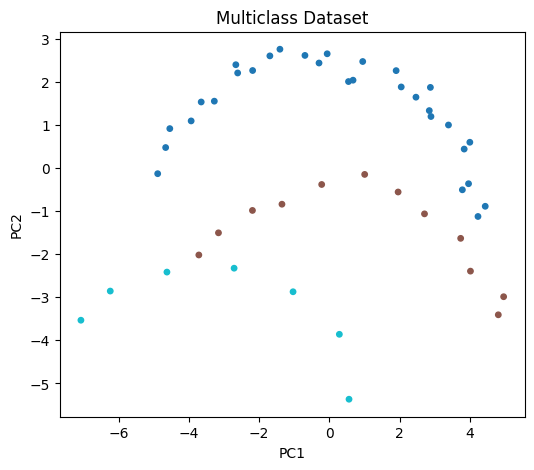

In [38]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


class RealisticManifoldDataset:

    def __init__(self, save_dir="datasets"):
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

    # ===============================
    # BINARY
    # ===============================
    def generate_binary(self, n_samples=800, imbalance_ratio=0.2,
                        n_features=8, filename="binary.csv"):

        n_min = int(n_samples * imbalance_ratio)
        n_maj = n_samples - n_min

        theta = np.linspace(0.2, np.pi - 0.2, n_maj)
        x1 = 3.5 * np.cos(theta)
        y1 = 2.5 * np.sin(theta)
        X_majority = np.vstack([x1, y1]).T
        X_majority += np.random.normal(0, 0.15, X_majority.shape)

        theta2 = np.linspace(0.2, np.pi - 0.2, n_min)
        x2 = 3.2 * np.cos(theta2) + 0.5
        y2 = -1.2 - 2.2 * np.sin(theta2)
        X_minority = np.vstack([x2, y2]).T
        X_minority += np.random.normal(0, 0.12, X_minority.shape)

        X = np.vstack([X_majority, X_minority])
        y = np.array([0]*n_maj + [1]*n_min)

        X = self._embed(X, n_features)
        X = np.nan_to_num(X)

        self._save_csv(X, y, filename)
        return X, y

    # ===============================
    # MULTICLASS
    # ===============================
    def generate_multiclass(self, n_samples=1200,
                            n_features=15, filename="multi.csv"):

        ratios = [0.6, 0.25, 0.15]
        counts = [int(r * n_samples) for r in ratios]

        X_list, y_list = [], []

        theta0 = np.linspace(0.2, np.pi - 0.2, counts[0])
        theta1 = np.linspace(0.2, np.pi - 0.2, counts[1])
        theta2 = np.linspace(0.2, np.pi - 0.2, counts[2])

        x0 = 3.5 * np.cos(theta0)
        y0 = 2.8 * np.sin(theta0)
        X0 = np.vstack([x0, y0]).T
        X0 += np.random.normal(0, 0.15, X0.shape)

        x1 = 3.3 * np.cos(theta1) + 1.2
        y1 = 2.3 * np.sin(theta1) - 1.5
        X1 = np.vstack([x1, y1]).T
        X1 += np.random.normal(0, 0.12, X1.shape)

        x2 = 3.1 * np.cos(theta2) - 1.2
        y2 = 2.0 * np.sin(theta2) - 3.0
        X2 = np.vstack([x2, y2]).T
        X2 += np.random.normal(0, 0.1, X2.shape)

        X_list.extend([X0, X1, X2])
        y_list.extend([
            np.full(len(X0), 0),
            np.full(len(X1), 1),
            np.full(len(X2), 2)
        ])

        X = np.vstack(X_list)
        y = np.concatenate(y_list)

        X = self._embed(X, n_features)
        X = np.nan_to_num(X)

        self._save_csv(X, y, filename)
        return X, y

    # ===============================
    # EMBEDDING
    # ===============================
    def _embed(self, X, n_features):
        if n_features <= 2:
            return X
        R = np.random.randn(2, n_features)
        X = X @ R
        return StandardScaler().fit_transform(X)

    # ===============================
    # SAVE CSV WITH HEADER
    # ===============================
    def _save_csv(self, X, y, filename):
        cols = [f"feature_{i}" for i in range(X.shape[1])]
        df = pd.DataFrame(X, columns=cols)
        df["class"] = y

        path = os.path.join(self.save_dir, filename)
        df.to_csv(path, index=False)
        print(f"Saved CSV to: {path}")

    # ===============================
    # VISUALIZATION
    # ===============================
    def visualize(self, X, y, title="Dataset"):
        pca = PCA(n_components=2)
        X_2d = pca.fit_transform(X)

        plt.figure(figsize=(6,5))
        plt.scatter(X_2d[:,0], X_2d[:,1], c=y, cmap='tab10', s=15)
        plt.title(title)
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.show()


# ===============================
# CALLING CODE
# ===============================
if __name__ == "__main__":

    gen = RealisticManifoldDataset("datasets")

    X_bin, y_bin = gen.generate_binary(
        n_samples=50,
        imbalance_ratio=0.2,
        n_features=8,
        filename="binary_clean.csv"
    )
    gen.visualize(X_bin, y_bin, "Binary Dataset")

    X_multi, y_multi = gen.generate_multiclass(
        n_samples=50,
        n_features=15,
        filename="multi_clean.csv"
    )
    gen.visualize(X_multi, y_multi, "Multiclass Dataset")